In [11]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

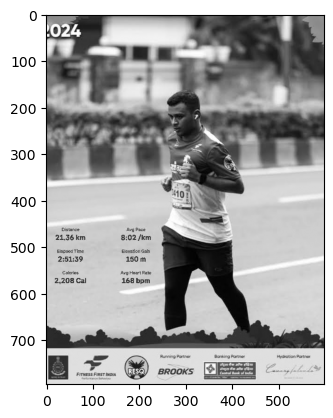

In [6]:
image=cv2.imread("D:/ippr/experiment_1/image.jpg")
#converting to grey scale 
image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image,cmap='gray')

Performing region splitting 

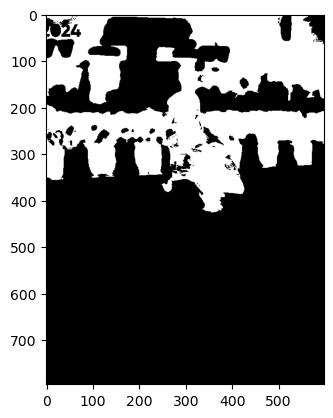

In [22]:
#defining seed point 
seed=(200,300)
#calculating height and width of the image 
h,w=image.shape
## initializing a list for visited and segmened nodes 
visited=np.zeros((h,w), dtype=np.uint8)
segmented=np.zeros((h,w),dtype=np.uint8)
# gets the intensity value at 200,300
seed_value=image[seed]
#initializes a queue and adds the seed pixel now we move outwards in a BFS style 
queue=deque([seed])
# mark seed as visited 
visited[seed]=1

# define the neighbours by 8 connectivity 
neighbours = [(-1,-1),(-1,0),(-1,1),
               (0,-1)       ,(0,1),
               (1,-1),(1,0),(1,1)]

threshold=80

while queue:
    x,y=queue.popleft() #<= pops the seed 
    segmented[x,y]=255 
    for dx,dy in neighbours: #<= from the 2D array of neighbours picks one 
        nx,ny=x+dx,y+dy #<= adds it to teh popped values i.e seed 
        if 0 <=nx <h and 0<=ny<w and not visited[nx,ny]: #<= checks if the neighbour is in the bound of the image
            if abs(int(image[nx,ny]) - int(seed_value)) <= threshold:
                #if the difference at pixel nx,ny is smaller than seed add the point to que
                queue.append((nx,ny)) #<== now pixel around this will be considered 
                # marking this as visited 
                visited[nx,ny]=1

#dislaying the segmented result 
plt.imshow(segmented,cmap='gray')



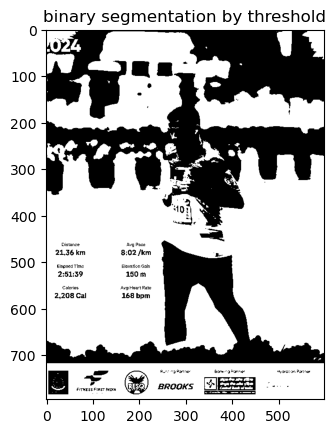

Final number of regions: 143


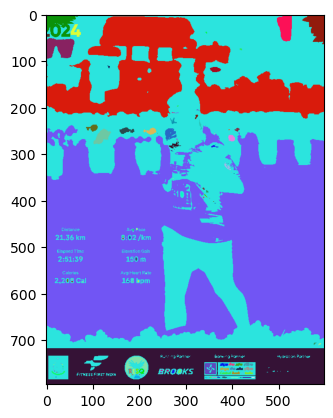

In [ ]:
# converts image into binary scale via a thrshold to seperate connecte regions 
_,binary=cv2.threshold(image,127,255,cv2.THRESH_BINARY)
# assigns labels / id to connected regions 
num_labels,labels=cv2.connectedComponents(binary)
plt.title("binary segmentation by threshold")
plt.imshow(binary,cmap='gray')
plt.show()

#calculating the mean of regions
region_mean={}
for label in range(num_labels):
    pixels=image[labels==label]
    if len(pixels) > 0:
        region_mean[label]=np.mean(pixels)

h,w =labels.shape
neighbors={i:set() for i in range(num_labels)}
for i in range(h):
    for j in range(w):
        current = labels[i, j]

        # check right and down neighbors (avoid duplicates)
        for dx, dy in [(1, 0), (0, 1)]:
            ni, nj = i + dx, j + dy
            if ni < h and nj < w:
                neighbor = labels[ni, nj]
                if neighbor != current:
                    neighbors[current].add(neighbor)
                    neighbors[neighbor].add(current)

parent = list(range(num_labels))

def find(x):
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(a, b):
    pa, pb = find(a), find(b)
    if pa != pb:
        parent[pb] = pa

threshold = 10

for r in range(num_labels):
    for n in neighbors[r]:
        if abs(region_mean[r] - region_mean[n]) <= threshold:
            union(r, n)

new_labels = np.zeros_like(labels)

for i in range(h):
    for j in range(w):
        new_labels[i, j] = find(labels[i, j])

print("Final number of regions:", len(set(parent)))

# Assign random colors
colors = np.random.randint(0, 255, (num_labels, 3), dtype=np.uint8)

colored = colors[new_labels]

plt.imshow( image , cmap="gray")
plt.imshow( binary , cmap="gray")
plt.imshow(colored, cmap="gray")


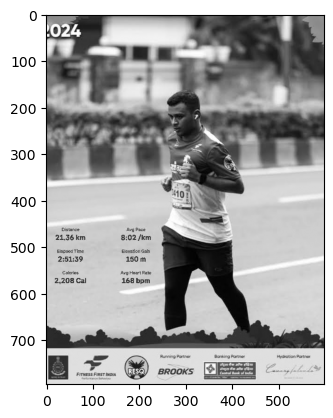

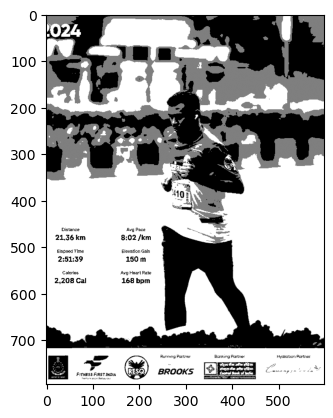

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [37]:
import cv2
import numpy as np

# Convert image to 1D array of pixels
pixel_values = image.reshape((-1, 1))
pixel_values = np.float32(pixel_values)

K = 3  # number of regions

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            100, 0.2)

_, labels, centers = cv2.kmeans(
    pixel_values,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)

segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(image.shape)

plt.imshow(image,cmap="gray")
plt.show()
plt.figure()
plt.imshow(segmented_image,cmap="gray")
plt.show()
plt.figure()